## **Нелинейные модели против южной погоды**

### Задачи:

Предложить компании BikeSouth новую, более гибкую модель для прогнозирования спроса на велосипеды.

Ключевые шаги к достижению этой цели:

- Изучить предоставленную компанией baseline-модель — линейную регрессию.
- Обучить новые модели — kNN и дерево решений.
- Провести подбор гиперпараметров с помощью библиотеки Optuna.
- Сравнить результаты всех подходов, выбрать лучший и аргументировать выбор.

### Признаки в датасете

- `Temperature`	Температура воздуха в градусах Цельсия (°C).	Градус Цельсия, °C.
- `Humidity`	Относительная влажность воздуха.	Процент водяного пара в воздухе.
- `Windspeed`	Скорость ветра.	Метр в секунду.
- `Visibility`	Видимость (в десятках метров).	Десять метров.
- `Dew Point Temperature`	Точка росы (°C).	Градус Цельсия, °C.
- `Solar Radiation`	Солнечная радиация (MJ/m²).	Мегаджоуль на квадратный метр, МДж/м², или MJ/m².
- `Rainfall`	Количество осадков (мм).	Миллиметр, мм.
- `Snowfall`	Количество снега (см).	Сантиметр, см.
- `Seasons`	Времена года: Winter, Spring, Summer, Autumn.	Winter — зима, Spring — весна, Summer — лето, Autumn — осень.
- `Holiday`	Был ли в этот день выходной или праздничный день.	Holiday — выходной или праздник, No Holiday — будний день.
- `Functioning Day`	Были ли велосипеды арендованы в рабочее время.	Yes — да, функциональные часы, No — нет, техническое обслуживание станций проката.

- Несколько колонок `Time_Period`	Каждая запись в датасете относится к одному из пяти временных периодов:

- `Night` — c 00:00 по 05:59;
- `Morning` — с 06:00 по 09:59.
- `Daytime` — с 10:00 по 15:59.
- `Evening` — с 16:00 по 19:59;
- `Late Evening` — с 20:00 по 23:59.	True и False.

- Данные о периоде `Daytime` — это базовое состояние. Запись, у которой в четырёх колонках c временным промежуткам указано значение `False`, автоматически относится к периоду Daytime.

## **Часть 1. Работа с базовой моделью**

Сперва вы познакомитесь с тем, как работает baseline-модель, которую использовала компания BikeSouth до того, как обратилась к вам.

Компания предоставила:

* Pickle-файл — готовый обученный пайплайн без исходного кода. Доступен по пути здесь: `'/datasets/baseline_linear_regression_pipeline.pkl'`.

* Тренировочную и тестовую выборки, которые можно использовать для оценки модели. Они расположены здесь:

  * `'/datasets/ds_s14_train_data.csv'`;
  * `'/datasets/ds_s14_test_data.csv'`.


Базовую модель не нужно обучать заново — достаточно загрузить её и проверить качество.

**Совет:**
1. Убедитесь, что у вас есть доступ к `baseline_linear_regression_pipeline.pkl`, `ds_s14_train_data.csv` и `ds_s14_test_data.csv`.

2. Разделите тестовый набор на признаки `X` и целевую переменную `y`.

3. Загрузите .pkl-файл — это готовый пайплайн, который сам обрабатывает данные и делает предсказания. Модель автоматически применяет трансформации и возвращает прогнозы.

4. Посчитайте RMSE, MAE и R² — эти результаты нужны для оценки ваших улучшенных моделей в дальнейшей работе.

>Техническая напоминание: для работы с PKL-файлом нужно установить библиотеку joblib.

### Подготовка среды и библиотек

In [1]:
! pip install "scikit-learn==1.6.1" "numpy==1.26.4" -q
! pip install phik -q
! pip install category-encoders -q
! pip install optuna -q

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from phik import phik_matrix
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import KFold, cross_validate, train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.inspection import permutation_importance
import optuna
import joblib
import warnings

warnings.filterwarnings('ignore')

In [3]:
# # Cоздаем файл requirements.txt с фиксированными версиями всех пакетов (если потребуется)
# ! pip freeze > requirements.txt

### Загружаем базовую модель линейной регрессии и предоставленный датасеты

In [4]:
baseline_linear = joblib.load('/datasets/baseline_linear_regression_pipeline.pkl')

In [5]:
df_train = pd.read_csv('/datasets/ds_s14_train_data.csv')
df_test = pd.read_csv('/datasets/ds_s14_test_data.csv')

In [6]:
TARGET = 'Rented Bike Count'

In [7]:
X_train_full = df_train.drop(columns = [TARGET])
y_train_full = df_train[TARGET]

In [8]:
y_train_pred = baseline_linear.predict(X_train_full)
mae_train = mean_absolute_error(y_train_full, y_train_pred)
rmse_train = np.sqrt(mean_squared_error(y_train_full, y_train_pred))
r2_train = r2_score(y_train_full, y_train_pred)

In [9]:
X_test = df_test.drop(columns = [TARGET])
y_test = df_test[TARGET]

### Проверяем качество базовой модели 

In [10]:
y_test_pred = baseline_linear.predict(X_test)
mae_test = mean_absolute_error(y_test, y_test_pred)
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))
r2_test = r2_score(y_test, y_test_pred)

In [11]:
result_baseline = pd.DataFrame({
    'MAE': [mae_train, mae_test],
    'RMSE': [rmse_train, rmse_test],
    'R2': [r2_train, r2_test]
}, index=['Train', 'Test']).round(3)
display(result_baseline)

,MAE,RMSE,R2
Train,309.078,412.526,0.593
Test,312.599,411.564,0.586


<div style="background: #B0E0E6; padding: 5px; border: 1px solid SteelBlue; border-radius: 5px;"><font color='black'><u><b>
 Комментарий
</b></u></font><br /><font color='black'> 

Базовая модель показывает стабильные результаты на тренировочных и тестовых данных: метрики `MAE` и `R²` близки (≈309–313 и ≈0.59 соответственно), что свидетельствует об отсутствии сильного переобучения. Однако высокое значение `RMSE` (≈411) по сравнению с `MAE` указывает на наличие значительных выбросов в предсказаниях. Модель объясняет около 59% дисперсии целевой переменной и требует дальнейшей настройки для улучшения качества и устойчивости.

</font></div>

<div class="alert alert-block alert-success">✔️
    

__Комментарий от ревьюера__

Супер, старайся, пожалуйста, придерживаться этой стратегии в дальнейших проектах =)
</div>

## **Часть 2. Улучшение модели — kNN и дерево решений**

Ваша задача — предложить более гибкую модель прогноза спроса на велосипеды, которая учитывает нюансы погоды и поведение клиентов.

Вы будете экспериментировать с моделями kNN и деревьями решений, используя подбор гиперпараметров Optuna.

**Шаг 1. Изучение данных**

Проведите исследовательский анализ данных:
1. Посмотрите на распределение целевой переменной `Rented Bike Count`. Определите, есть ли у неё выбросы или сильные сезонные колебания.
2. Постройте графики зависимости спроса от разных признаков.
3. Сравните спрос в разные сезоны и праздничные дни.
4. Рассчитайте корреляцию между признаками и целевой переменной.

**Совет:**

Не нужно сразу всё усложнять: начните с базовых графиков и описательной статистики.



---



### Изучение исходных данных

In [12]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7008 entries, 0 to 7007
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Temperature               7008 non-null   float64
 1   Humidity(%)               6758 non-null   float64
 2   Wind speed (m/s)          6798 non-null   float64
 3   Visibility (10m)          6749 non-null   float64
 4   Dew point temperature     7008 non-null   float64
 5   Solar Radiation (MJ/m2)   6798 non-null   float64
 6   Rainfall(mm)              6746 non-null   float64
 7   Snowfall (cm)             6745 non-null   float64
 8   Seasons                   7008 non-null   object 
 9   Holiday                   7008 non-null   object 
 10  Functioning Day           7008 non-null   object 
 11  Time_Period_Evening       7008 non-null   bool   
 12  Time_Period_Late Evening  7008 non-null   bool   
 13  Time_Period_Morning       7008 non-null   bool   
 14  Time_Per

In [13]:
# Проверим наличие дубликатов и вместе с тем познакомимся с данными
df_train.drop_duplicates()

,Temperature,Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature,Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day,Time_Period_Evening,Time_Period_Late Evening,Time_Period_Morning,Time_Period_Night,Rented Bike Count
0,20.3,35.0,2.4,2000.0,4.3,0.46,0.0,0.0,Autumn,Holiday,Yes,True,False,False,False,1237
1,25.4,55.0,3.2,2000.0,15.6,0.15,0.0,0.0,Autumn,No Holiday,Yes,True,False,False,False,2468
2,-6.9,39.0,1.6,2000.0,-18.5,0.00,0.0,0.0,Winter,No Holiday,Yes,False,True,False,False,186
3,-5.2,37.0,2.2,2000.0,-17.6,0.00,0.0,0.0,Winter,No Holiday,Yes,False,False,False,True,254
4,23.4,34.0,2.1,2000.0,6.6,2.84,0.0,0.0,Autumn,No Holiday,Yes,False,False,False,False,1686
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7003,-4.2,40.0,0.9,1216.0,-15.8,0.00,0.0,0.0,Winter,No Holiday,Yes,True,False,False,False,410
7004,2.9,51.0,0.8,1119.0,-6.2,0.00,0.0,0.0,Spring,No Holiday,Yes,False,False,False,True,163
7005,5.3,73.0,0.7,2000.0,0.8,0.01,0.0,0.0,Autumn,No Holiday,Yes,False,False,True,False,1142
7006,4.4,64.0,1.4,2000.0,-1.8,0.00,0.0,0.0,Autumn,No Holiday,Yes,False,False,False,True,362


In [14]:
def show_missing_stats(tmp0):
    """
    Функция для отображения статистики пропущенных значений в DataFrame.
    """
    missing_stats = pd.DataFrame({
        'Кол-во пропусков': tmp0.isnull().sum(),
        'Доля пропусков': tmp0.isnull().mean()
    })
    missing_stats = missing_stats[missing_stats['Кол-во пропусков'] > 0]
    
    if missing_stats.empty:
        return "Пропусков в данных нет"
    
    #Сортировка по количеству пропусков
    missing_stats = missing_stats.sort_values('Кол-во пропусков', ascending=False)
    
    # Форматируем при выводе через Styler
    return (missing_stats.style.format({'Доля пропусков': '{:.4f}'}).background_gradient(cmap='coolwarm'))
show_missing_stats(df_train)

,Кол-во пропусков,Доля пропусков
Snowfall (cm),263,0.0375
Rainfall(mm),262,0.0374
Visibility (10m),259,0.0370
Humidity(%),250,0.0357
Wind speed (m/s),210,0.0300
Solar Radiation (MJ/m2),210,0.0300


In [15]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1752 entries, 0 to 1751
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Temperature               1752 non-null   float64
 1   Humidity(%)               1680 non-null   float64
 2   Wind speed (m/s)          1700 non-null   float64
 3   Visibility (10m)          1680 non-null   float64
 4   Dew point temperature     1752 non-null   float64
 5   Solar Radiation (MJ/m2)   1700 non-null   float64
 6   Rainfall(mm)              1688 non-null   float64
 7   Snowfall (cm)             1691 non-null   float64
 8   Seasons                   1752 non-null   object 
 9   Holiday                   1752 non-null   object 
 10  Functioning Day           1752 non-null   object 
 11  Time_Period_Evening       1752 non-null   bool   
 12  Time_Period_Late Evening  1752 non-null   bool   
 13  Time_Period_Morning       1752 non-null   bool   
 14  Time_Per

In [16]:
show_missing_stats(df_test)

,Кол-во пропусков,Доля пропусков
Humidity(%),72,0.0411
Visibility (10m),72,0.0411
Rainfall(mm),64,0.0365
Snowfall (cm),61,0.0348
Wind speed (m/s),52,0.0297
Solar Radiation (MJ/m2),52,0.0297


<div style="background: #B0E0E6; padding: 5px; border: 1px solid SteelBlue; border-radius: 5px;"><font color='black'><u><b>
 Комментарий
</b></u></font><br /><font color='black'> 

Данных загружены корректно в тренировочных данных содержатся 7008 объектов и 16 признаков (включая целевую переменную), в тестовых 1752 объекта.

В тренировочных и тестовых данных имеются пропуски в признаках `Humidity(%), Visibility (10m), Rainfall(mm), Snowfall (cm), Wind speed (m/s), Solar Radiation (MJ/m2)` все признаки числовые и в дальнейшем будут заполнены медианными значениями.

Дальнейшее изучение данных будем проводить только на тренировочных данных, после чего подготовим пайплайн для обработки исходных данных.

</font></div>

In [17]:
# Ознакомимся с распредением числовых значения
df_train.select_dtypes(include=['number']).describe()

,Temperature,Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature,Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Rented Bike Count
count,7008.000000,6758.000000,6798.000000,6749.000000,7008.000000,6798.000000,6746.000000,6745.000000,7008.000000
mean,12.812914,58.200503,1.725228,1435.156764,4.021490,0.569885,0.146902,0.074752,705.606022
std,11.924688,20.340317,1.042956,607.291049,13.033377,0.866142,1.164118,0.438189,646.311790
min,-17.500000,0.000000,0.000000,27.000000,-30.600000,0.000000,0.000000,0.000000,0.000000
25%,3.300000,42.000000,0.900000,936.000000,-4.700000,0.000000,0.000000,0.000000,190.750000
50%,13.500000,57.000000,1.500000,1691.000000,5.000000,0.010000,0.000000,0.000000,504.500000
75%,22.400000,74.000000,2.300000,2000.000000,14.800000,0.940000,0.000000,0.000000,1070.000000
max,39.400000,98.000000,7.400000,2000.000000,26.800000,3.520000,35.000000,8.800000,3556.000000


In [18]:
#Выводим ункальные значение для всех признаков
for column in df_train.columns:
    print(f'Уникальные значения в {column}:')
    print(df_train[column].unique())
    print(f'Количество уникальных значений в {column}:')
    print(df_train[column].nunique())


Уникальные значения в Temperature:
[ 20.3  25.4  -6.9  -5.2  23.4   9.7  17.4  18.1  36.7   7.    0.6   9.9
 -15.9  22.6  14.5   9.4  16.5  29.8  18.9  11.6   7.5  11.3   8.   23.8
  28.9  -9.6  -5.4  13.   12.6   0.5  13.8   7.1  21.7  -8.1   1.1  25.9
  16.4  -5.3  11.8  -8.5  -1.1   4.8   6.7   4.6   4.1   8.3  28.3  28.2
 -15.7  -1.2  18.3  -2.4  18.2  11.2  -0.8   5.4  22.8  -0.4  26.5  -0.2
  -7.6  12.   26.7  13.2  27.9  -2.5  32.3   8.8  -4.1   3.    6.9 -10.6
   3.1  20.9   5.1  33.7  10.6   7.8   8.9  -3.7   4.5   8.7  18.6  20.5
   5.7  24.8  -9.2   9.8  21.5  27.4  15.1  28.6  32.4  19.2 -11.2 -10.3
  24.4  19.   31.1  22.   26.   11.5  19.8  -4.6   3.8  15.5  16.9  35.2
  -4.5   2.6  12.8   2.9  16.2   2.5  36.2   6.2  21.1  20.1   6.6  30.2
  22.2  -5.9  10.2  24.   -7.9  -1.5  17.1  20.8  23.5   5.8   9.2  33.4
   2.1  37.2  -4.4   8.5  14.1  -1.7  36.3   5.9  23.7   3.4  32.8  17.6
  -9.7   7.7  27.8  11.7  15.8  21.2  13.4   3.3  -0.6  21.9   2.4  -8.6
   0.1  -6.6  16

In [19]:
df_train.columns

Index(['Temperature', 'Humidity(%)', 'Wind speed (m/s)', 'Visibility (10m)',
       'Dew point temperature', 'Solar Radiation (MJ/m2)', 'Rainfall(mm)',
       'Snowfall (cm)', 'Seasons', 'Holiday', 'Functioning Day',
       'Time_Period_Evening', 'Time_Period_Late Evening',
       'Time_Period_Morning', 'Time_Period_Night', 'Rented Bike Count'],
      dtype='object')

### Гистограммы для числовых признаков

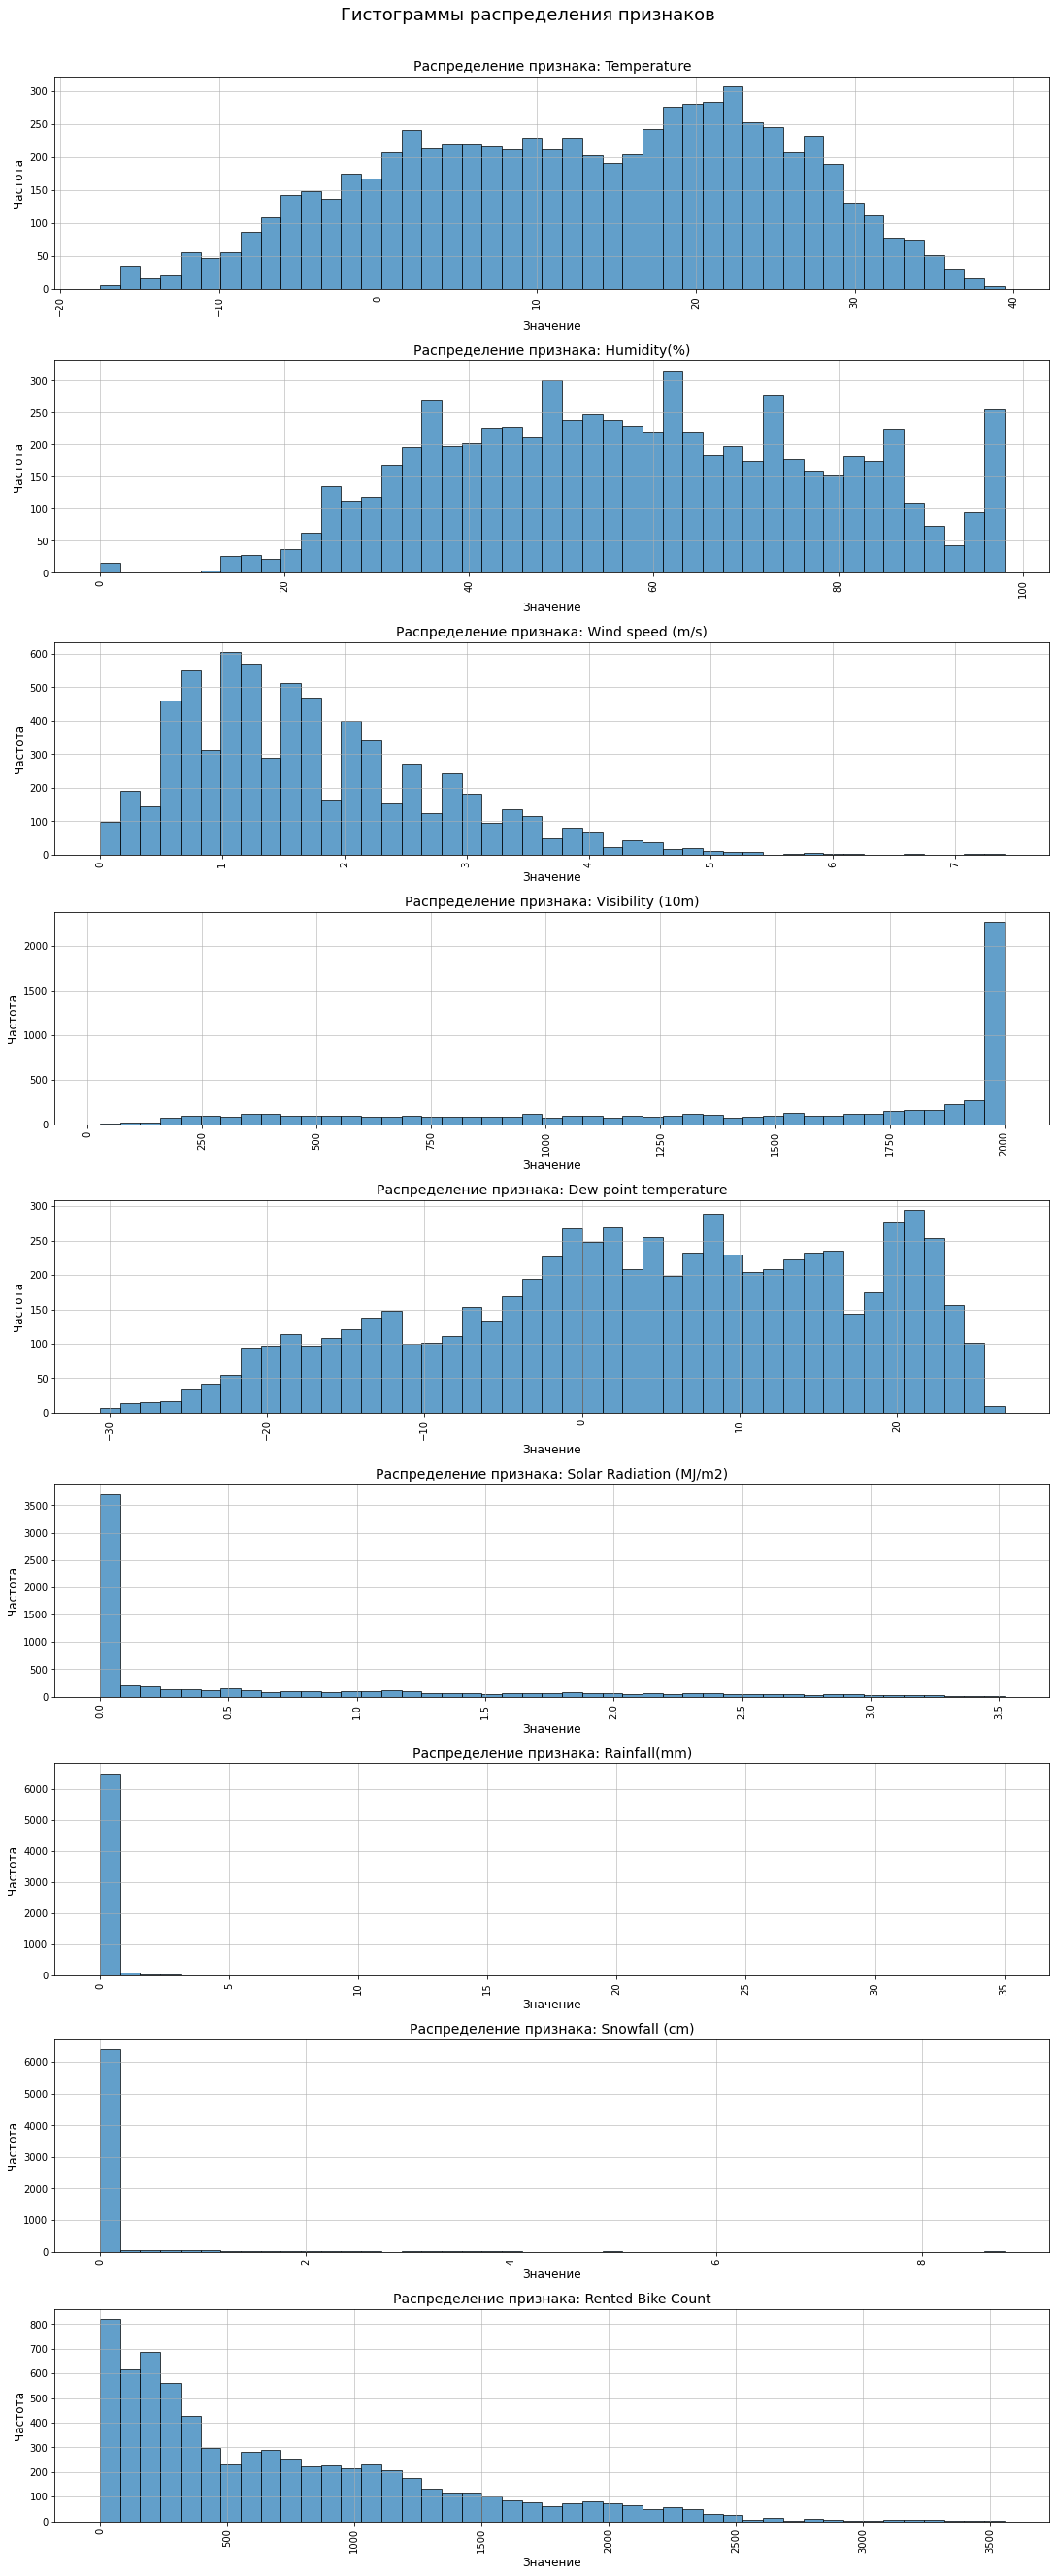

In [20]:
# Рассмотрим распредение числовых значений
def full_plot_bigger(df, columns):
    # Получаем список колонок
    n = len(columns)
    
    # Создаем фигуру с нужным количеством подграфиков
    fig, axes = plt.subplots(n, 1, figsize=(15, 4*n), constrained_layout=True)

    # Создаем гистограммы для каждого признака
    for i, column in enumerate(columns):
        axes[i].hist(df[column], bins=45, edgecolor='black', alpha=0.7)
        axes[i].set_xlabel('Значение', fontsize=12)
        axes[i].set_ylabel('Частота', fontsize=12)
        axes[i].set_title(f'Распределение признака: {column}', fontsize=14)
        axes[i].grid(True, alpha=0.7)
        axes[i].tick_params(axis='x', rotation=90)
    
    plt.suptitle('Гистограммы распределения признаков', fontsize=18, y=1.02)
    return fig, axes

fig, axes = full_plot_bigger(df_train, df_train[['Temperature', 'Humidity(%)', 'Wind speed (m/s)', 'Visibility (10m)',
       'Dew point temperature', 'Solar Radiation (MJ/m2)', 'Rainfall(mm)', 'Snowfall (cm)', 'Rented Bike Count']].columns)
plt.show()

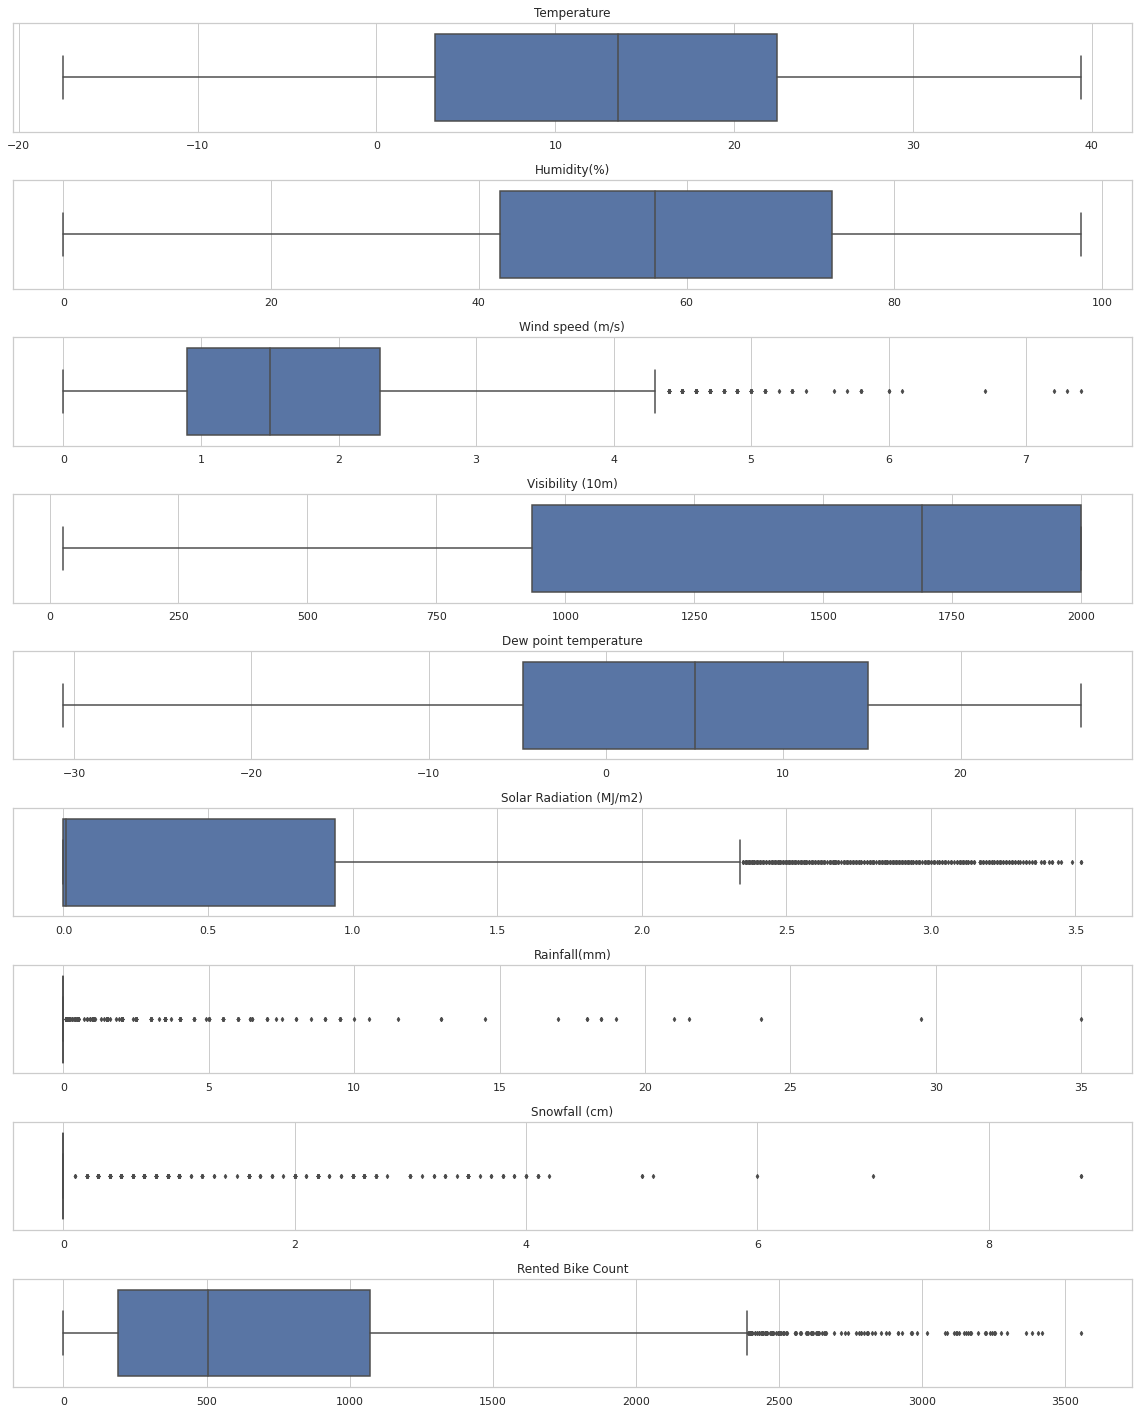

In [21]:
def box_plot(df,columns):
    sns.set(style="whitegrid")

    n = len(columns)
    plt.figure(figsize=(16, 2.2 * n))

    for i, col in enumerate(columns, start=1):
        plt.subplot(n, 1, i)
        sns.boxplot(x=df[col], color="#4C72B0", fliersize=3)
        plt.title(col)
        plt.xlabel("")

    plt.tight_layout()
    plt.show()
box_plot(df_train, df_train[['Temperature', 'Humidity(%)', 'Wind speed (m/s)', 'Visibility (10m)',
       'Dew point temperature', 'Solar Radiation (MJ/m2)', 'Rainfall(mm)', 'Snowfall (cm)', 'Rented Bike Count']].columns)

<div style="background: #B0E0E6; padding: 5px; border: 1px solid SteelBlue; border-radius: 5px;"><font color='black'><u><b>
 Комментарий
</b></u></font><br /><font color='black'> 

В признаках `Rainfall(mm), Snowfall (cm)` заметны выбросы, однако они могут быть особенностями климата, поэтому удалять их не будем.

</font></div>

### Столбчатые диаграммы для категориальных признаков

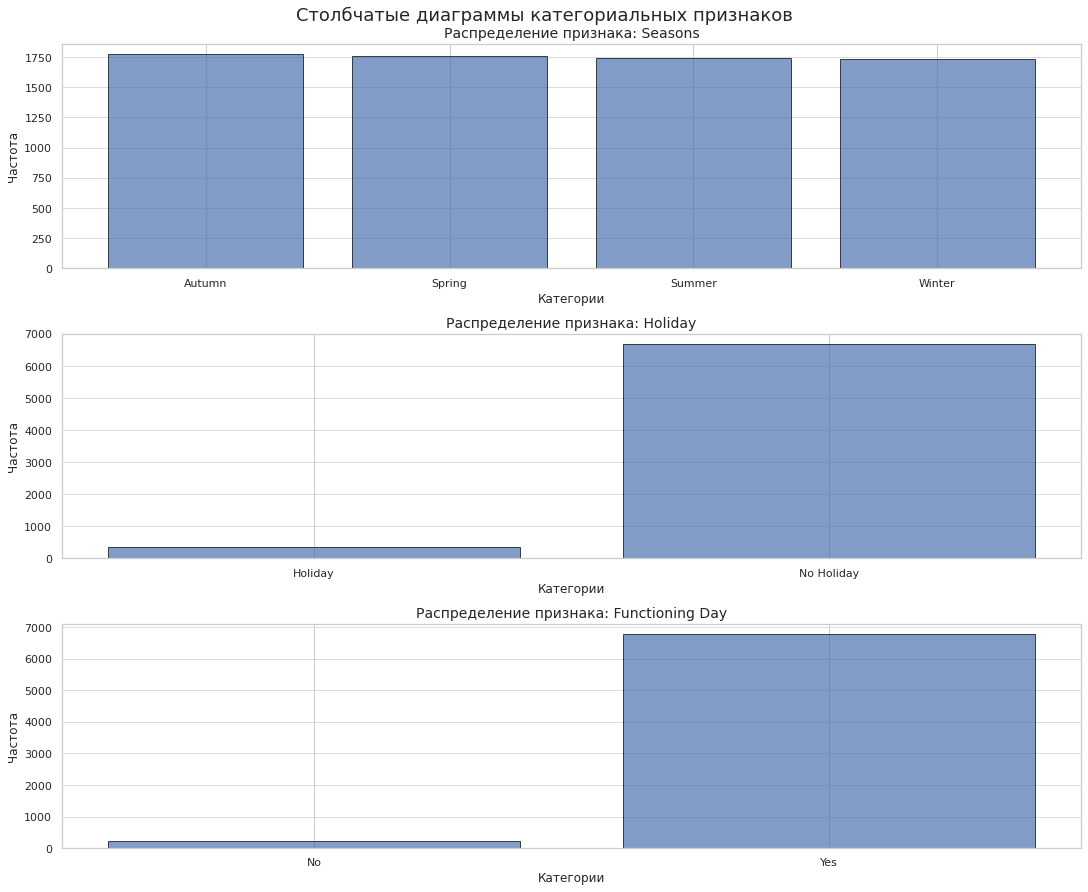

In [22]:
def plot_categorical_bars(df, categorical_columns):
    n = len(categorical_columns)
    # Создаём фигуру с вертикальным расположением подграфиков
    fig, axes = plt.subplots(n, 1, figsize=(15, 4 * n), constrained_layout=True)

    # Если только один признак, axes не является списком – приводим к списку
    if n == 1:
        axes = [axes]

    for i, col in enumerate(categorical_columns):
        # Подсчитываем частоты категорий (можно также использовать normalize=True для долей)
        counts = df[col].value_counts().sort_index()  # сортировка по категориям для наглядности

        # Строим столбчатую диаграмму
        axes[i].bar(counts.index.astype(str), counts.values, edgecolor='black', alpha=0.7)
        axes[i].set_xlabel('Категории', fontsize=12)
        axes[i].set_ylabel('Частота', fontsize=12)
        axes[i].set_title(f'Распределение признака: {col}', fontsize=14)
        axes[i].grid(True, alpha=0.7, axis='y')
        axes[i].tick_params(axis='x', rotation=0)

    plt.suptitle('Столбчатые диаграммы категориальных признаков', fontsize=18, y=1.02)
    return fig, axes
fig, axes = plot_categorical_bars(df_train, df_train[['Seasons', 'Holiday', 'Functioning Day']].columns)
plt.show()

### Анализ связи категориальных признаков с целевой переменной Rented Bike Count

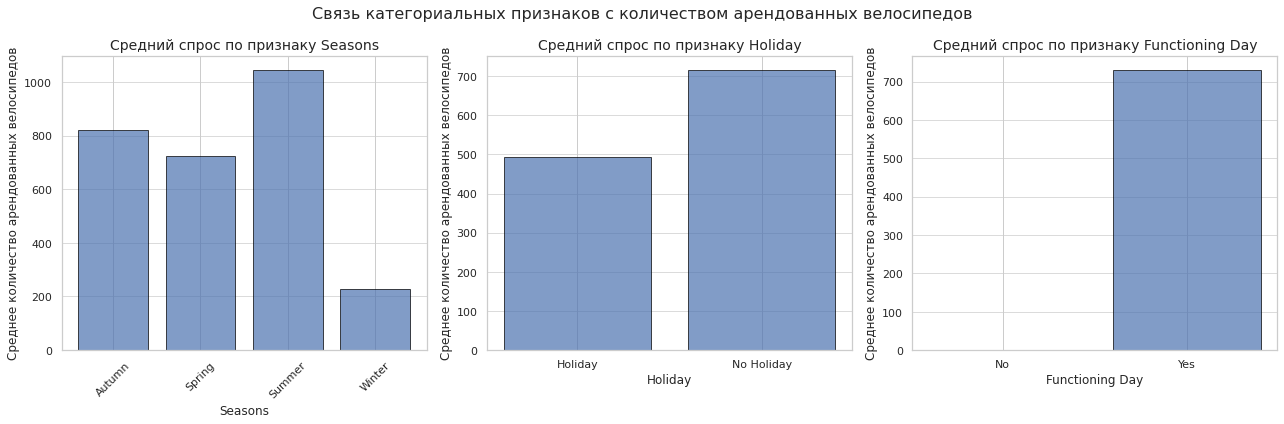

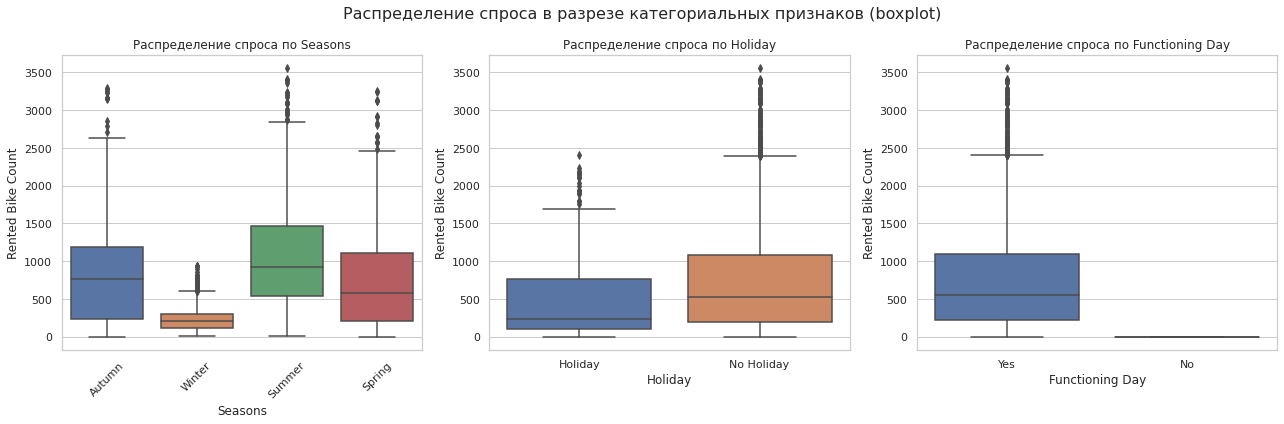

In [23]:
categorical_features = ['Seasons', 'Holiday', 'Functioning Day']

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Связь категориальных признаков с количеством арендованных велосипедов', fontsize=16)

for i, col in enumerate(categorical_features):
    # Группируем по категориям и вычисляем среднее
    grouped = df_train.groupby(col)['Rented Bike Count'].mean().reset_index()
    
    # Столбчатая диаграмма со средним спросом
    axes[i].bar(grouped[col].astype(str), grouped['Rented Bike Count'], edgecolor='black', alpha=0.7)
    axes[i].set_xlabel(col, fontsize=12)
    axes[i].set_ylabel('Среднее количество арендованных велосипедов', fontsize=12)
    axes[i].set_title(f'Средний спрос по признаку {col}', fontsize=14)
    axes[i].grid(True, alpha=0.7, axis='y')
    axes[i].tick_params(axis='x', rotation=45 if col == 'Seasons' else 0)

plt.tight_layout()
plt.show()

# Боксплоты для каждого признака
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Распределение спроса в разрезе категориальных признаков (boxplot)', fontsize=16)

for i, col in enumerate(categorical_features):
    sns.boxplot(data=df_train, x=col, y='Rented Bike Count', ax=axes[i])
    axes[i].set_title(f'Распределение спроса по {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Rented Bike Count')
    axes[i].tick_params(axis='x', rotation=45 if col == 'Seasons' else 0)

plt.tight_layout()
plt.show()

<div style="background: #B0E0E6; padding: 5px; border: 1px solid SteelBlue; border-radius: 5px;"><font color='black'><u><b>
 Комментарий
</b></u></font><br /><font color='black'> 

По графикам отображения взаимосвязи целевой переменной с категориальными признаками можно заметить, что наибольший спрос летом и не в выходные/праздничные дни. (очевидно что в период ТО спроса нет)

</font></div>

### Матрица корреляции

In [24]:
correlation_matrix = df_train.phik_matrix(interval_cols=df_train.select_dtypes(include=['float64', 'int64']).columns.tolist())

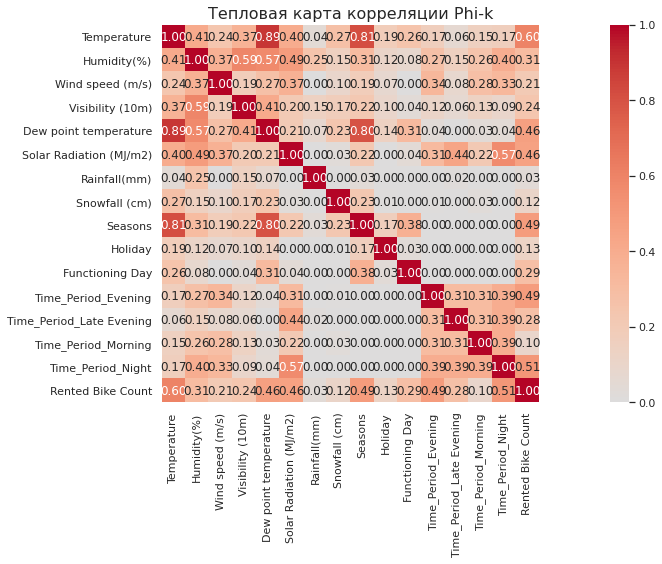

In [25]:
# Создаем тепловую карту
plt.figure(figsize=(20, 8))
sns.heatmap(correlation_matrix, 
            annot=True,     # Показать числа в ячейках
            fmt='.2f',      # Формат чисел: 2 знака после запятой
            cmap='coolwarm', # Цветовая схема
            center=0,       # Центр цветовой шкалы на 0
            square=True)    # Квадратные ячейки

plt.title('Тепловая карта корреляции Phi-k', fontsize=16)
plt.tight_layout()
plt.show()

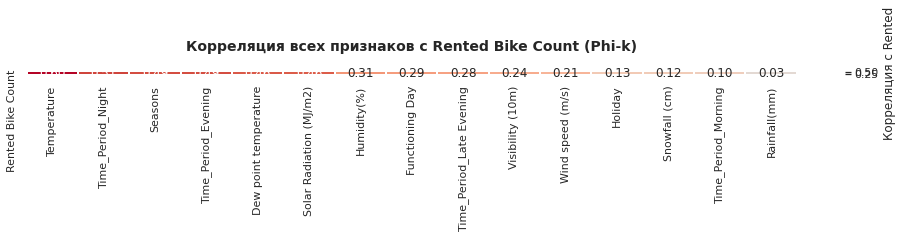

In [26]:
# Извлекаем корреляцию с weight и удаляем сам weight из списка
rented_corr = correlation_matrix['Rented Bike Count'].drop('Rented Bike Count')

# Сортируем по убыванию корреляции
rented_corr_sorted = rented_corr.sort_values(ascending=False)
# Создаем DataFrame с корреляциями с Rented
rented_corr_df = pd.DataFrame(rented_corr_sorted).T  # Транспонируем в одну строку

# Создаем тепловую карту
plt.figure(figsize=(14, 3))
sns.heatmap(rented_corr_df, 
            annot=True,     # Показать числа в ячейках
            fmt='.2f',      # Формат чисел: 2 знака после запятой
            cmap='coolwarm', # Цветовая схема
            center=0,       # Центр цветовой шкалы на 0
            square=False,   # Не обязательно квадратные ячейки
            cbar_kws={'label': 'Корреляция с Rented'},
            linewidths=1,   # Границы между ячейками
            linecolor='white')

plt.title('Корреляция всех признаков с Rented Bike Count (Phi-k)', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

### Создание дополнительных признаков

In [27]:
def create_features(df):
    # Был дождь или нет
    df['is_rain'] = (df['Rainfall(mm)'] > 0).astype(int)
    # Произведение температуры и влажности (без этого признака результат минимально, но лучше)
#     df['Temp_Humidity'] = df['Temperature'] * df['Humidity(%)'] 
    # Был снег или нет
    df['is_snow'] = (df['Snowfall (cm)'] > 0).astype(int)
    df['is_good_weather'] = ((df['Rainfall(mm)'] == 0) & 
                                     (df['Snowfall (cm)'] == 0) & (df['Temperature'] > 5)).astype(int)
    return df

<div style="background: #B0E0E6; padding: 5px; border: 1px solid SteelBlue; border-radius: 5px;"><font color='black'><u><b>
 Комментарий
</b></u></font><br /><font color='black'> 

Функция создает дополнительные признаки `is_rain, is_snow, is_good_weather` и в дальнейшем будет встроена в пайплайн моделей.

</font></div>

**Шаг 2. Разделение данных на тренировочную и валидационную выборки**

Используйте на этом этапе данные файла `ds_s14_train_data.csv`. Тестовый набор нужен только для финальной оценки модели после обучения и подбора гиперпараметров.

Подготовка данных вам понадобится, чтобы обучить модель и оценить её качество через валидацию.

---



### Разделение выборки на тренировочную и валидационную

In [28]:
RANDOM_STATE = 42

In [29]:
# Делим выборки на тестовую и тренировочную
train_df, valid_df = train_test_split (df_train, test_size=0.2, shuffle = True, random_state=RANDOM_STATE)

X_train = train_df.drop(columns=[TARGET])
y_train = train_df[TARGET]
X_valid = valid_df.drop(columns=[TARGET])
y_valid = valid_df[TARGET]

<div style="background: #B0E0E6; padding: 5px; border: 1px solid SteelBlue; border-radius: 5px;"><font color='black'><u><b>
 Комментарий
</b></u></font><br /><font color='black'> 

Так как в целевом признаке есть класс, который встречается всего один раз во всём датасете стратификацию не используем, в противном случае этот единственный класс пришлось бы удалять или изменять, что не совсем корректно.

</font></div>

In [30]:
print('Размеры для обучения:  X -', X_train.shape,'y -', y_train.shape)
print('Размеры для валидации: X -', X_valid.shape,'y -', y_valid.shape)

Размеры для обучения:  X - (5606, 15) y - (5606,)
Размеры для валидации: X - (1402, 15) y - (1402,)


**Шаг 3. Обучение новых моделей**

kNN и деревья решений могут уловить нелинейные зависимости, недоступные линейной регрессии. Пора это проверить!

1. Подготовьте пайплайн для каждой модели:
    * Выполните предобработку данных.
    * Инициализизируйте регрессионные модели kNN и дерево решений.
4. Настройте базовые параметры моделей — например, `n_neighbors` для kNN, `max_depth` для дерева.

**Совет:**

Начинайте с базовых параметров, чтобы убедиться, что пайплайн работает. Оптимизацию параметров вы сделаете на следующем шаге.

---



<div class="alert alert-block alert-success">✔️
    

__Комментарий от ревьюера__

Разделение на train/valid сделано в корректной пропорции 80/20

### Подготовка пайплайнов и инициализация новых моделей

In [31]:
# Собираем выборки признаков
numeric_features = X_train.select_dtypes(include=['number']).columns.tolist()
new_features = ['is_rain', 'is_snow', 'is_good_weather']
all_numeric = numeric_features + new_features
categorical_features = ['Seasons', 'Functioning Day', 'Holiday']
print(numeric_features)
print(categorical_features)

['Temperature', 'Humidity(%)', 'Wind speed (m/s)', 'Visibility (10m)', 'Dew point temperature', 'Solar Radiation (MJ/m2)', 'Rainfall(mm)', 'Snowfall (cm)']
['Seasons', 'Functioning Day', 'Holiday']


In [32]:
# Пробная модель KNN
knn = KNeighborsRegressor(n_neighbors = 5)

In [33]:
# Пробная модель дерева решений
tree_regress = DecisionTreeRegressor(max_depth = 10, criterion = 'absolute_error')

In [34]:
# Собираем трансформеры для признаков
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, all_numeric),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
])

In [35]:
# Создаём трансформер для сбора новых признаков
feature_creator = FunctionTransformer(create_features)

In [36]:
# Собираем пайплайны для KNN и Дерева решений
pipeline_knn = Pipeline([
    ('feature_creator', feature_creator),
    ('preprocessor', preprocessor),
    ('regressor', knn)
])

pipeline_tree = Pipeline([
    ('feature_creator', feature_creator),
    ('preprocessor', preprocessor),  # для дерева масштабирование не нужно, но можно оставить
    ('regressor', tree_regress)
])

In [37]:
# Обучаем пайплайн KNN
pipeline_knn.fit(X_train, y_train)

Pipeline(steps=[('feature_creator',
                 FunctionTransformer(func=<function create_features at 0x7fb1707498b0>)),
                ('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Temperature', 'Humidity(%)',
                                                   'Wind speed (m/s)',
                                                   'Visibility (10m)',
                                                   'Dew point temperature',
                                                   'Solar Radiation (MJ/m2)',
                                                   'Rainfall(mm)',
                                                   'Snowfall (cm)', 'is_rain',
                                                   'is_snow',
                                                   'is_good_weather']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['Seasons', 'Functioning Day',
                                                   'Holiday'])])),
                ('regressor', KNeighborsRegressor())])

In [38]:
# Обучаем пайплайн Дерева решений
pipeline_tree.fit(X_train, y_train)

Pipeline(steps=[('feature_creator',
                 FunctionTransformer(func=<function create_features at 0x7fb1707498b0>)),
                ('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Temperature', 'Humidity(%)',
                                                   'Wind speed (m/s)',
                                                   'Visibility (10m)',
                                                   'Dew point temperature',
                                                   'Solar Radiation (MJ/m2)',
                                                   'Rainfall(mm)',
                                                   'Snowfall (cm)', 'is_rain',
                                                   'is_snow',
                                                   'is_good_weather']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['Seasons', 'Functioning Day',
                                                   'Holiday'])])),
                ('regressor',
                 DecisionTreeRegressor(criterion='absolute_error',
                                       max_depth=10))])

<div class="alert alert-block alert-success">✔️
    

__Комментарий от ревьюера__

Учтено

### Выполняем проверку с пробными параметрами моделей

In [39]:
y_pred_train_knn = pipeline_knn.predict(X_train)

In [40]:
y_pred_valid_knn = pipeline_knn.predict(X_valid)

In [41]:
y_pred_train_tree = pipeline_tree.predict(X_train)

In [42]:
y_pred_valid_tree = pipeline_tree.predict(X_valid)

In [43]:
mae_train_knn = mean_absolute_error(y_train, y_pred_train_knn)
rmse_train_knn = np.sqrt(mean_squared_error(y_train, y_pred_train_knn))
r2_train_knn = r2_score(y_train, y_pred_train_knn)

mae_train_tree = mean_absolute_error(y_train, y_pred_train_tree)
rmse_train_tree = np.sqrt(mean_squared_error(y_train, y_pred_train_tree))
r2_train_tree = r2_score(y_train, y_pred_train_tree)

mae_valid_knn = mean_absolute_error(y_valid, y_pred_valid_knn)
rmse_valid_knn = np.sqrt(mean_squared_error(y_valid, y_pred_valid_knn))
r2_valid_knn = r2_score(y_valid, y_pred_valid_knn)

mae_valid_tree = mean_absolute_error(y_valid, y_pred_valid_tree)
rmse_valid_tree = np.sqrt(mean_squared_error(y_valid, y_pred_valid_tree))
r2_valid_tree = r2_score(y_valid, y_pred_valid_tree)

In [44]:
result_knn_tree = pd.DataFrame({
    'MAE KNN': [mae_train_knn, mae_valid_knn],
    'RMSE KNN': [rmse_train_knn, rmse_valid_knn],
    'R2 KNN': [r2_train_knn, r2_valid_knn],
    'MAE TREE': [mae_train_tree, mae_valid_tree],
    'RMSE TREE': [rmse_train_tree, rmse_valid_tree],
    'R2 TREE': [r2_train_tree, r2_valid_tree]
}, index=['Train', 'Valid']).round(3)
display(result_knn_tree)

,MAE KNN,RMSE KNN,R2 KNN,MAE TREE,RMSE TREE,R2 TREE
Train,218.042,328.691,0.742,194.938,344.101,0.717
Valid,275.780,414.302,0.585,277.631,430.967,0.551


<div style="background: #B0E0E6; padding: 5px; border: 1px solid SteelBlue; border-radius: 5px;"><font color='black'><u><b>
 Комментарий
</b></u></font><br /><font color='black'> 

При проверке работоспособности моделей с случайными гиперпараметрами можно сделать вывод, что модели выполняют свои функции. Требуется взвешенный подбор гиперпараметров.

</font></div>

<div class="alert alert-block alert-success">✔️
    

__Комментарий от ревьюера__

Учтено

**Шаг 4. Подбор гиперпараметров с Optuna**

Компания хочет точную модель. Optuna поможет найти лучшие гиперпараметры для kNN и дерева, чтобы снизить ошибки прогноза.


1. Определите функцию цели для Optuna.

2. Настройте диапазоны гиперпараметров.

3. Запустите оптимизацию и сохраните лучшие параметры.

**Совет:**

Не бойтесь сначала экспериментировать с небольшими диапазонами, а потом расширять их, если модель не уловит зависимости.

---



### Подбор гиперпараметров с Optuna для Tree

In [45]:
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

In [46]:
def searching_three(trial):
    params = {
        "criterion": trial.suggest_categorical('criterion', ['squared_error', 'friedman_mse', 'absolute_error', 'poisson']),
        "max_depth": trial.suggest_int("max_depth", 3, 15),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 50),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 30),
       "max_features": trial.suggest_categorical('max_features', ['sqrt', 'log2', None])
    }

    model = DecisionTreeRegressor(**params, random_state=RANDOM_STATE)
    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    scoring = {
        'MAE': 'neg_mean_absolute_error',
        'RMSE': 'neg_root_mean_squared_error',
        'R2': 'r2'
    }

    cv_results = cross_validate(
        pipeline, X_train, y_train,
        cv=cv,
        scoring=scoring,
        return_train_score=False
    )

    # Извлекаем средние значения метрик (преобразуем отрицательные в положительные)
    mae = -cv_results['test_MAE'].mean()
    rmse = -cv_results['test_RMSE'].mean()
    r2 = cv_results['test_R2'].mean()
    
    return mae, rmse, r2

In [47]:
# Создаём исследование
study_tree = optuna.create_study(
    directions=['minimize', 'minimize', 'maximize'],
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE)
)

study_tree.optimize(searching_three, n_trials=60, show_progress_bar=True)

# Получаем лучшие параметры (по критерию – MAE)
best_trial_tree = study_tree.best_trials[1]  # можно выбрать по нужному критерию
print("Лучшие гиперпараметры:", best_trial_tree.params)
print("Лучшее MAE:", best_trial_tree.values[0])
print("Лучшее RMSE:", best_trial_tree.values[1])
print("Лучшее R2:", best_trial_tree.values[2])

[I 2026-03-29 11:12:18,511] A new study created in memory with name: no-name-e87b8765-9996-492f-9278-bf37f65c4bd4


  0%|          | 0/60 [00:00<?, ?it/s]

[I 2026-03-29 11:12:18,760] Trial 0 finished with values: [325.30506157112796, 462.76692361896903, 0.488245576797438] and parameters: {'criterion': 'friedman_mse', 'max_depth': 5, 'min_samples_split': 9, 'min_samples_leaf': 2, 'max_features': 'sqrt'}.
[I 2026-03-29 11:12:18,948] Trial 1 finished with values: [325.7902894610282, 461.758150186895, 0.4904891469230047] and parameters: {'criterion': 'friedman_mse', 'max_depth': 5, 'min_samples_split': 10, 'min_samples_leaf': 10, 'max_features': 'sqrt'}.
[I 2026-03-29 11:12:19,142] Trial 2 finished with values: [303.24623500545965, 436.24671757948573, 0.5449921628206436] and parameters: {'criterion': 'squared_error', 'max_depth': 8, 'min_samples_split': 40, 'min_samples_leaf': 6, 'max_features': 'log2'}.
[I 2026-03-29 11:12:19,346] Trial 3 finished with values: [322.93634328041713, 464.8454406642878, 0.48250546512194353] and parameters: {'criterion': 'poisson', 'max_depth': 15, 'min_samples_split': 41, 'min_samples_leaf': 10, 'max_features':

### Подбор гиперпараметров с Optuna для KNN

In [48]:
def searching_knn(trial):
    # Гиперпараметры для KNeighborsRegressor
    params = {
        "n_neighbors": trial.suggest_int("n_neighbors", 3, 20),
        "weights": trial.suggest_categorical("weights", ["uniform", "distance"]),
        "metric": trial.suggest_categorical("metric", ["euclidean", "manhattan", "minkowski"])
    }

    # Если метрика minkowski, добавляем параметр p
    if params["metric"] == "minkowski":
        params["p"] = trial.suggest_int("p", 1, 2)

    model = KNeighborsRegressor(**params)
    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    scoring = {
        'MAE': 'neg_mean_absolute_error',
        'RMSE': 'neg_root_mean_squared_error',
        'R2': 'r2'
    }

    cv_results = cross_validate(
        pipeline, X_train, y_train,
        cv=cv,
        scoring=scoring,
        return_train_score=False
    )

    mae = -cv_results['test_MAE'].mean()
    rmse = -cv_results['test_RMSE'].mean()
    r2 = cv_results['test_R2'].mean()
    
    return mae, rmse, r2

In [49]:
study_knn = optuna.create_study(
    directions=['minimize', 'minimize', 'maximize'],
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE)
)

study_knn.optimize(searching_knn, n_trials=100, show_progress_bar=True)

# Вывод лучших параметров и метрик (по критерию – RMSE)
best_trial_knn = study_knn.best_trials[1]
print("Лучшие гиперпараметры KNN:", best_trial_knn.params)
print("Лучшее MAE KNN:", best_trial_knn.values[0])
print("Лучшее RMSE KNN:", best_trial_knn.values[1])
print("Лучшее R2 KNN:", best_trial_knn.values[2])

[I 2026-03-29 11:12:42,117] A new study created in memory with name: no-name-82186016-1ab9-41a6-8dcf-5aaae2e1c10d


  0%|          | 0/100 [00:00<?, ?it/s]

[I 2026-03-29 11:12:42,518] Trial 0 finished with values: [282.1685006472696, 410.79812310814685, 0.5964327488547883] and parameters: {'n_neighbors': 9, 'weights': 'uniform', 'metric': 'euclidean'}.
[I 2026-03-29 11:12:42,823] Trial 1 finished with values: [280.1729914324014, 419.61099313670877, 0.5789975031742314] and parameters: {'n_neighbors': 4, 'weights': 'uniform', 'metric': 'minkowski', 'p': 2}.
[I 2026-03-29 11:12:43,496] Trial 2 finished with values: [261.6514403296188, 393.5287214027561, 0.6294956931256023] and parameters: {'n_neighbors': 6, 'weights': 'distance', 'metric': 'manhattan'}.
[I 2026-03-29 11:12:43,807] Trial 3 finished with values: [281.41532122134396, 411.14936140800444, 0.5957033591720993] and parameters: {'n_neighbors': 8, 'weights': 'uniform', 'metric': 'minkowski', 'p': 2}.
[I 2026-03-29 11:12:44,476] Trial 4 finished with values: [261.6514403296188, 393.5287214027561, 0.6294956931256023] and parameters: {'n_neighbors': 6, 'weights': 'distance', 'metric': 'm

**Шаг 5. Кросс-валидация новых моделей**

1. Проведите кросс-валидацию kNN и дерева решений с оптимальными гиперпараметрами.
2. Сравните метрики с baseline-моделью.
3. Определите, какая модель показывает лучшие результаты на тренировочной выборке.

**Совет:**

Используйте визуализации (например, столбчатую диаграмму или ящик с усами), чтобы оценить разброс метрик и стабильность моделей.


---



### Кросс-валидация новых моделей

In [50]:
# Создаём модели с оптимальными параметрами
tree_opt = DecisionTreeRegressor(**best_trial_tree.params, random_state=RANDOM_STATE)
knn_opt = KNeighborsRegressor(**best_trial_knn.params)

In [51]:
pipeline_tree_opt = Pipeline([('feature_creator', feature_creator), ("preprocessor", preprocessor), ("model", tree_opt)])
pipeline_knn_opt = Pipeline([('feature_creator', feature_creator), ("preprocessor", preprocessor), ("model", knn_opt)])

In [52]:
# Функция для получения метрик по фолдам
def get_cv_metrics(pipeline, X, y, cv, scoring):
    cv_results = cross_validate(
        pipeline, X, y, cv=cv,
        scoring=scoring,
        return_train_score=False
    )
    mae = -cv_results['test_MAE']
    rmse = -cv_results['test_RMSE']
    r2 = cv_results['test_R2']   # R2 уже положительный
    return {'MAE': mae, 'RMSE': rmse, 'R2': r2}

In [53]:
scoring = {
    'MAE': 'neg_mean_absolute_error',
    'RMSE': 'neg_root_mean_squared_error',
    'R2': 'r2'
}

In [54]:
# Кросс-валидация baseline
baseline_metrics = get_cv_metrics(baseline_linear, X_train, y_train, cv, scoring)

# Кросс-валидация дерева решений
tree_metrics = get_cv_metrics(pipeline_tree_opt, X_train, y_train, cv, scoring)

# Кросс-валидация kNN
knn_metrics = get_cv_metrics(pipeline_knn_opt, X_train, y_train, cv, scoring)

In [55]:
# Сбор статистик в DataFrame
results = []
for model_name, metrics in [('Baseline', baseline_metrics), ('Decision Tree', tree_metrics), ('KNN', knn_metrics)]:
    for metric in ['MAE', 'RMSE', 'R2']:
        for fold, value in enumerate(metrics[metric], 1):
            results.append({
                'Model': model_name,
                'Metric': metric,
                'Fold': fold,
                'Value': value
            })
df_results = pd.DataFrame(results)

# Сводная таблица средних и стандартных отклонений
summary = df_results.groupby(['Model', 'Metric'])['Value'].agg(['mean', 'std']).round(4)
print("Сводная статистика метрик по фолдам:")
print(summary)

Сводная статистика метрик по фолдам:
                          mean      std
Model         Metric                   
Baseline      MAE     309.7229   2.5650
              R2        0.5915   0.0103
              RMSE    413.4110   2.7243
Decision Tree MAE     272.4827   4.2962
              R2        0.6125   0.0222
              RMSE    402.5613  10.9087
KNN           MAE     261.8727   7.0362
              R2        0.6406   0.0231
              RMSE    387.6179  11.2897


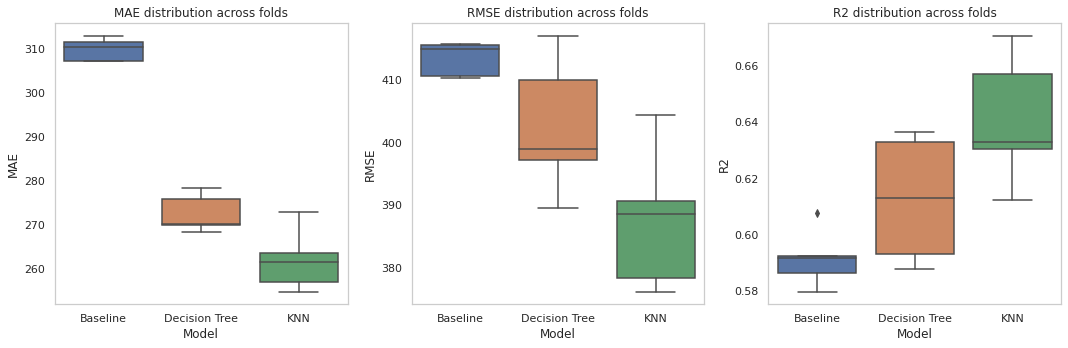

In [56]:
# Визуализация (ящик с усами)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, metric in enumerate(['MAE', 'RMSE', 'R2']):
    sns.boxplot(data=df_results[df_results['Metric']==metric], x='Model', y='Value', ax=axes[i])
    axes[i].set_title(f'{metric} distribution across folds')
    axes[i].set_ylabel(metric)
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

<div style="background: #B0E0E6; padding: 5px; border: 1px solid SteelBlue; border-radius: 5px;"><font color='black'><u><b>
 Комментарий
</b></u></font><br /><font color='black'> 

По результату подбора гиперпараметров лучшие результаты показывает модель KNN с параметрами `'n_neighbors': 11, 'weights': 'distance', 'metric': 'manhattan'`. В дальнейшем она и будет проверена на тестовой выборке.

</font></div>

**Шаг 6. Составление отчёта по моделям**

1. Составьте таблицу с метриками для трёх моделей: baseline, лучшей kNN и лучшего дерева решений.
2. Добавьте визуализацию с распределением метрик, если необходимо.

Подготовьте выводы:
* Какая модель лучше справляется с прогнозом?
* Какие признаки, по вашему мнению, особенно важны?


**Совет:**

Старайтесь объяснить результаты в бизнес-контексте. Примеры выводов на языке заказчика:
* «Эта модель лучше реагирует на дождь».
* «Температура и влажность сильно влияют на спрос в пиковые часы».

---



<div class="alert alert-block alert-success">✔️
    

__Комментарий от ревьюера__

собрал итоговые метрики по фолдам, сделал сводную таблицу и boxplot

### Отчета по моделям

In [57]:
# Не понимаю зачем выводить сводную таблицу, по сути такое же задание было выше, но ладно...
print("Сводная статистика метрик по фолдам:")
print(summary)

Сводная статистика метрик по фолдам:
                          mean      std
Model         Metric                   
Baseline      MAE     309.7229   2.5650
              R2        0.5915   0.0103
              RMSE    413.4110   2.7243
Decision Tree MAE     272.4827   4.2962
              R2        0.6125   0.0222
              RMSE    402.5613  10.9087
KNN           MAE     261.8727   7.0362
              R2        0.6406   0.0231
              RMSE    387.6179  11.2897


<div style="background: #B0E0E6; padding: 5px; border: 1px solid SteelBlue; border-radius: 5px;"><font color='black'><u><b>
 Комментарий
</b></u></font><br /><font color='black'> 

На данный момент лучшие показатели у `модели KNN` (`наименьшее MAE и RMSE`, а так же наибольшее `R2`)

</font></div>

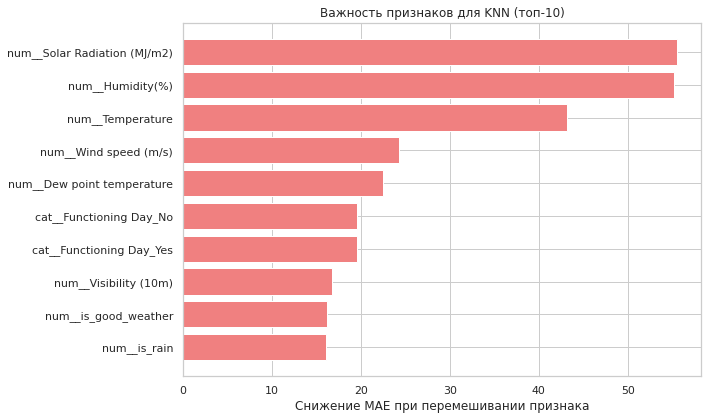

In [58]:
# Обучаем пайплайн
pipeline_knn_opt.fit(X_train, y_train)

# Извлекаем препроцессор и модель
preprocessor = pipeline_knn_opt.named_steps['preprocessor']
model = pipeline_knn_opt.named_steps['model']

# Преобразуем валидационные данные
X_valid_transformed = preprocessor.transform(X_valid)

# Вычисляем permutation importance на модели и преобразованных данных
perm_importance = permutation_importance(
    model,
    X_valid_transformed,
    y_valid,
    n_repeats=10,
    random_state=42,
    scoring='neg_mean_absolute_error'
)

# Имена признаков после преобразования
feature_names = preprocessor.get_feature_names_out()

# Создаём DataFrame
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': perm_importance.importances_mean
}).sort_values('importance', ascending=False)

# Визуализация
top_10 = importance_df.head(10)
plt.figure(figsize=(10, 6))
plt.barh(top_10['feature'], top_10['importance'], color='lightcoral')
plt.xlabel('Снижение MAE при перемешивании признака')
plt.title('Важность признаков для KNN (топ-10)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [59]:
importance_df['feature'].unique()

array(['num__Solar Radiation (MJ/m2)', 'num__Humidity(%)',
       'num__Temperature', 'num__Wind speed (m/s)',
       'num__Dew point temperature', 'cat__Functioning Day_No',
       'cat__Functioning Day_Yes', 'num__Visibility (10m)',
       'num__is_good_weather', 'num__is_rain', 'cat__Seasons_Autumn',
       'cat__Seasons_Winter', 'cat__Seasons_Spring', 'num__Rainfall(mm)',
       'cat__Seasons_Summer', 'num__is_snow', 'num__Snowfall (cm)',
       'cat__Holiday_Holiday', 'cat__Holiday_No Holiday'], dtype=object)

<div style="background: #B0E0E6; padding: 5px; border: 1px solid SteelBlue; border-radius: 5px;"><font color='black'><u><b>
 Комментарий
</b></u></font><br /><font color='black'> 

Для KNN модели наиболее важными признаками (по убыванию важности) являются:
    
       'num__Solar Radiation (MJ/m2)', 'num__Humidity(%)',
       'num__Temperature', 'num__Wind speed (m/s)',
       'num__Dew point temperature', 'cat__Functioning Day_No',
       'cat__Functioning Day_Yes', 'num__Visibility (10m)',
       'num__is_good_weather', 'num__is_rain'

</font></div>

**Шаг 7. Сохранение модели и отчёта**

1. Выберите финальную, лучшую модель и оцените её качество на тестовой выборке, чтобы понять, насколько хорошо она прогнозирует на новых данных.
2. Подготовьте тетрадку с кодом и комментариями: включите результаты всех экспериментов, метрики моделей, визуализации, а также обоснование выбора финальной модели.

**Совет:**

Документируйте каждый шаг. Объясняйте, почему выбраны те или иные гиперпараметры и подходы. В реальной бизнес-задаче эта привычка поможет вашим коллегам и руководству понимать решения и доверять модели.

---



### Обучение лучшей модели на всех тренировочных данный и проверка на тестовых

In [60]:
# Загружаем заново тренировочные данные, для чистоты эксперимента
X_train_full = df_train.drop(columns = [TARGET])
y_train_full = df_train[TARGET]

In [61]:
# Загружаем заново тестовые данные, для чистоты эксперимента
X_test = df_test.drop(columns = [TARGET])
y_test = df_test[TARGET]

In [62]:
# Обучаем пайплайн на всей обучающей выборке
pipeline_knn_opt.fit(X_train_full, y_train_full)

Pipeline(steps=[('feature_creator',
                 FunctionTransformer(func=<function create_features at 0x7fb1707498b0>)),
                ('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Temperature', 'Humidity(%)',
                                                   'Wind speed (m/s)',
                                                   'Visibility (10m)',
                                                   'Dew point temperature',
                                                   'Solar Radiation (MJ/m2)',
                                                   'Rainfall(mm)',
                                                   'Snowfall (cm)', 'is_rain',
                                                   'is_snow',
                                                   'is_good_weather']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['Seasons', 'Functioning Day',
                                                   'Holiday'])])),
                ('model',
                 KNeighborsRegressor(metric='manhattan', n_neighbors=11,
                                     weights='distance'))])

In [63]:
y_train_full_pred = pipeline_knn_opt.predict(X_train_full)
mae_knn_train = mean_absolute_error(y_train_full, y_train_full_pred)
rmse_knn_train = np.sqrt(mean_squared_error(y_train_full, y_train_full_pred))
r2_knn_train = r2_score(y_train_full, y_train_full_pred)

In [64]:
y_test_full_pred = pipeline_knn_opt.predict(X_test)
mae_knn_test = mean_absolute_error(y_test, y_test_full_pred)
rmse_knn_test = np.sqrt(mean_squared_error(y_test, y_test_full_pred))
r2_knn_test = r2_score(y_test, y_test_full_pred)

In [65]:
result_knn = pd.DataFrame({
    'MAE': [mae_knn_train, mae_knn_test],
    'RMSE': [rmse_knn_train, rmse_knn_test],
    'R2': [r2_knn_train, r2_knn_test]
}, index=['Train', 'Test']).round(3)
print('Результаты лучшей KNN модели:')
display(result_knn)
print('Результаты baseline модели:')
display(result_baseline)

Результаты лучшей KNN модели:


,MAE,RMSE,R2
Train,0.000,0.000,1.000
Test,250.501,370.534,0.664


Результаты baseline модели:


,MAE,RMSE,R2
Train,309.078,412.526,0.593
Test,312.599,411.564,0.586


<div style="background: #B0E0E6; padding: 5px; border: 1px solid SteelBlue; border-radius: 5px;"><font color='black'><u><b>
 Комментарий
</b></u></font><br /><font color='black'> 

Исходя из полученных метрик можно сделать вывод что итоговая модель хоть и предсказывает результат лучше базовой (baseline) модели, но все же допускает значительные ошибки (высокий `RMSE=370` значит что средний размер ошибок между предсказанными и фактическими значениями большой, что свидетельствуюет о выбросах в предсказаниях). И все же модель KNN объясяет больше предсказаний `R2 0,664 против 0,586 у базовой модели`
    
Сохранять модель и артефакты в задании вроде как не требуется, так что оставляю проект в виде одного файла - проекта

</font></div>

### **Дополнительное задание: реализация кастомного трансформера**

Простые признаки вроде температуры или влажности не всегда отражают реальную ситуацию. Чтобы модель могла лучше прогнозировать спрос на велосипеды, можно создавать новые признаки, которые учитывают особенности погоды или взаимодействия факторов.

1. Реализуйте класс с методами `fit` и `transform`.
2. Вставьте его в пайплайн перед моделью.
3. Убедитесь, что трансформер корректно работает с тренировочными данными.

**Совет:**  
Если вы решите реализовать трансформер, начинайте с простых комбинаций признаков, чтобы не усложнять модель слишком рано.


---



<div style="background: #B0E0E6; padding: 5px; border: 1px solid SteelBlue; border-radius: 5px;"><font color='black'><u><b>
 Комментарий
</b></u></font><br /><font color='black'> 

На данный момент нет ощущения что готов к этому заданию.

</font></div>

<div style="border:solid blue 3px; padding: 20px">
<div class="alert alert-block alert-success">✔️
    

__Коментарий от ревьюера__

    
Всё чудно😊. Твой проект так и просится на github =)   
    
Поздравляю с успешным завершением проекта 😊👍
И желаю успехов в новых работах 😊
